# Linear Regression Project - Diabetes Dataset

The goal of this notebook is to use Scikit-Learn to implement a complete machine learning project using **Scikit-Learn's diabetes dataset**.

## 1. Imports 

In [108]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

import joblib

from linear_regression import LinearRegression as LinearRegressionScratch

## 2. Load dataset

In [ ]:
# Load the diabetes dataset
df = pd.DataFrame(load_diabetes().data, columns=load_diabetes().feature_names)
df['target'] = load_diabetes().target # diabete progression measure after one year

In [15]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [16]:
df.info(), df.describe(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


(None,
                 age           sex           bmi            bp            s1  \
 count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
 mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
 std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
 min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
 25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
 50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
 75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
 max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   
 
                  s2            s3            s4            s5            s6  \
 count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
 mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17   
 std    4.761905e-02  4.761905e

In [20]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (442, 11)
Head:
         age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
Description:
                 age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  

We notice:

- **442 examples, 11 features**: age, sex, bmi, bp, s1, s2, s3, s4, s5, s6 and target.
- **No missing/null values**.
- When looking at the std line in the df.describe() output, we notice that all the features have a standard deviation of 4.76e-02, which is about 0.0476. And the means are all close to zero, meaning the **dataset is already normalized**. Sklearn did it already, so there’s no need for additional preprocessing on the features. 

## 3. Train and test datasets

In [21]:
# Prepare the data: target variable and features
X = df.drop("target", axis=1).values # features
y = df["target"].values # target

In [24]:
# Split datasets into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Train the model with Linear Regression model from scratch

In [94]:
# Train the scratch model
model_scratch = LinearRegressionScratch(learning_rate=0.1, n_iters=5000, batch_size=None)

In [95]:
# Fit the scratch model
model_scratch.fit(X_train, y_train)

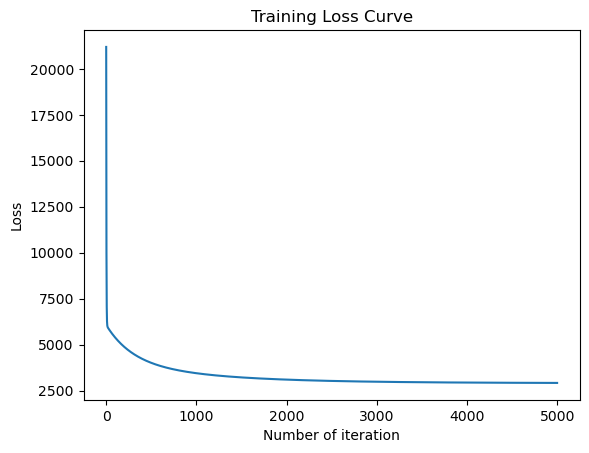

In [96]:
# Visualize the loss curve
plt.plot(model_scratch.losses)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [97]:
# Evaluate the scratch model
# Train set evaluation
predictions_scratch_train = model_scratch.predict(X_train)
mse_scratch_train = mean_squared_error(y_train, predictions_scratch_train)
r2_scratch_train = r2_score(y_train, predictions_scratch_train)

print("MSE Train (Scratch):", mse_scratch_train)
print("R² Train (Scratch):", r2_scratch_train)

MSE Train (Scratch): 2914.701553373165
R² Train (Scratch): 0.5203241217667509


In [98]:
# Test set evaluation
predictions_scratch = model_scratch.predict(X_test)
mse_scratch_test = mean_squared_error(y_test, predictions_scratch)
r2_scratch_test = r2_score(y_test, predictions_scratch)

print("MSE Test (Scratch):", mse_scratch_test)
print("R² Test (Scratch):", r2_scratch_test)

MSE Test (Scratch): 2866.882705603096
R² Test (Scratch): 0.45889003530225847


The loss continues to decrease, but at a slower rate—we’re approaching convergence. The training R² is 0.52 and the test R² is 0.46.

Note: the training R² is greater than the test R², but the difference is small (0.52 vs. 0.46). This isn’t significant overfitting.

## 5. Train the model with Linear Regression model from Scikit-Learn

In [99]:
# Train scikit-learn model
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [100]:
# Evaluate sklearn model
# Train set evaluation
predictions_sklearn_train = model_sklearn.predict(X_train)
mse_sklearn_train = mean_squared_error(y_train, predictions_sklearn_train)
r2_sklearn_train = r2_score(y_train, predictions_sklearn_train)

print("MSE Train (Sklearn):", mse_sklearn_train)
print("R² Train (Sklearn):", r2_sklearn_train)

MSE Train (Sklearn): 2868.549702835578
R² Train (Sklearn): 0.5279193863361497


In [101]:
# Test set evaluation
predictions_sklearn = model_sklearn.predict(X_test)
mse_sklearn_test = mean_squared_error(y_test, predictions_sklearn)
r2_sklearn_test = r2_score(y_test, predictions_sklearn)

print("MSE Test (Sklearn):", mse_sklearn_test)
print("R² Test (Sklearn):", r2_sklearn_test)

MSE Test (Sklearn): 2900.1936284934827
R² Test (Sklearn): 0.45260276297191926


The results from both linear regression models are close:

| Model    | R² Train | R² Test |
|----------|----------|---------|
| Scratch  | 0.520    | 0.459   |
| Sklearn  | 0.528    | 0.453   |

The from-scratch model using gradient descent is within less than 1% of sklearn’s optimal solution. This is a very strong validation.
And an R² of 0.45–0.53 on this dataset is not bad — linear regression has structural limitations, and the diabetes dataset contains non-linear relationships that this model cannot capture.

A more complex model would perform better, but that is not the goal here.

## 6. Dataset and fitting curve visualization

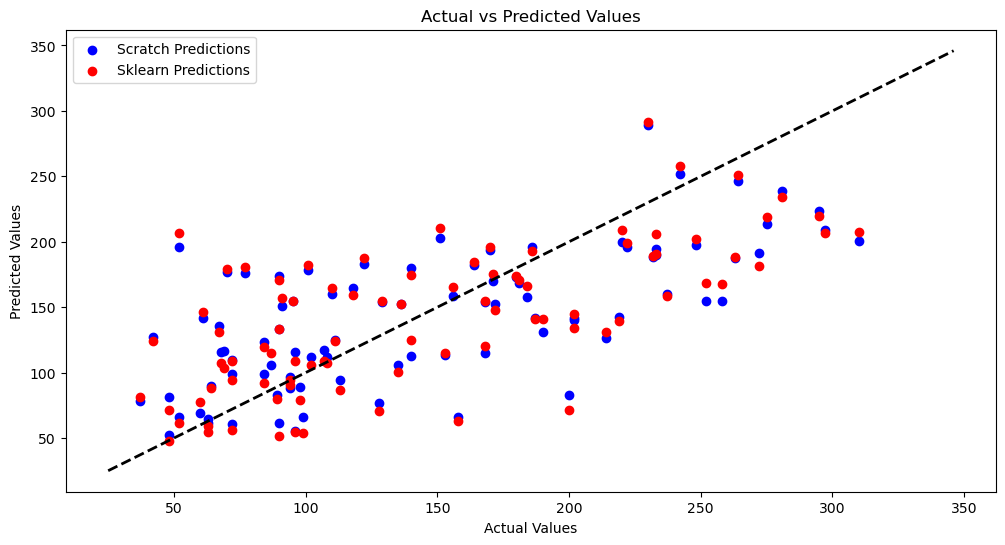

In [102]:
# Visualize the dataset and the predictions
plt.figure(figsize=(12, 6))
plt.scatter(y_test, predictions_scratch, color='blue', label='Scratch Predictions')
plt.scatter(y_test, predictions_sklearn, color='red', label='Sklearn Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

The blue and red points are almost on top of each other—visual confirmation that Scratch and scikit-learn models are making very similar predictions. 

The dotted diagonal line represents the perfect prediction. 

The points are generally clustered around this diagonal line but with noticeable variation—consistent with an R² of 0.45, which isn’t perfect but isn’t random either.

## 7. Save models

In [104]:
# Save both models
joblib.dump(model_scratch, "models/linear_regression_scratch.pkl")
joblib.dump(model_sklearn, "models/linear_regression_sklearn.pkl")

['models/linear_regression_sklearn.pkl']

In [105]:
# Verify that the models are saved correctly
loaded_scratch_model = joblib.load("models/linear_regression_scratch.pkl")
loaded_sklearn_model = joblib.load("models/linear_regression_sklearn.pkl")

In [106]:
# Predict the test set with the loaded models
predictions_loaded_scratch = loaded_scratch_model.predict(X_test)
predictions_loaded_sklearn = loaded_sklearn_model.predict(X_test)

In [109]:
# Compare predictions from loaded models with original predictions
np.allclose(predictions_scratch, predictions_loaded_scratch), np.allclose(predictions_sklearn, predictions_loaded_sklearn)

(True, True)